#### Project Objective
Barclays Bank facing high customer churn rate, and customer not keep using services, being a Data Scientist your task is to identify the companies problem so that they can get the real time insights and management can take decision accordingly, Previously banks were not getting timely insights and did not take decision timely, that costs high customer churn rate, the previous methodologies were old and not upto dated, presently bank needs live analysis and corrective measures to predict the future churn rate and live analysis.

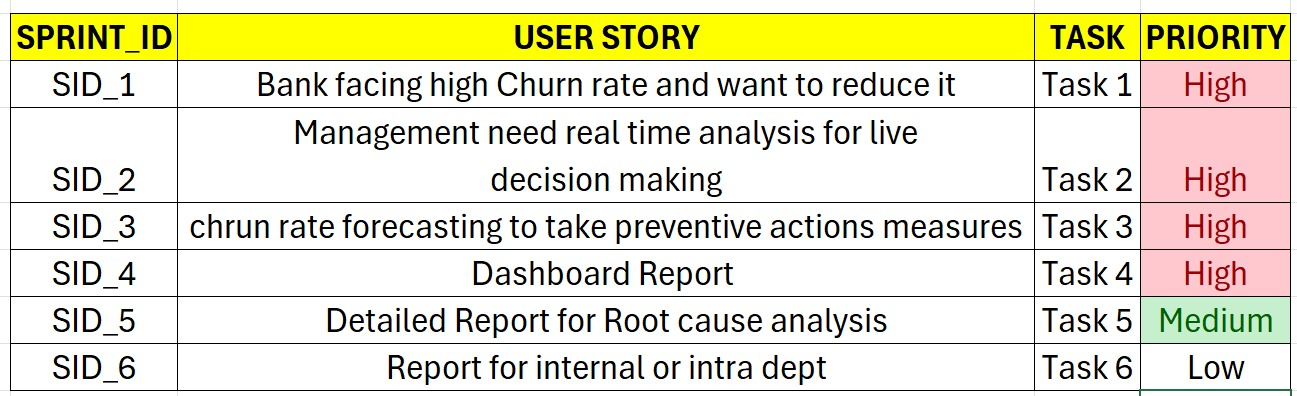


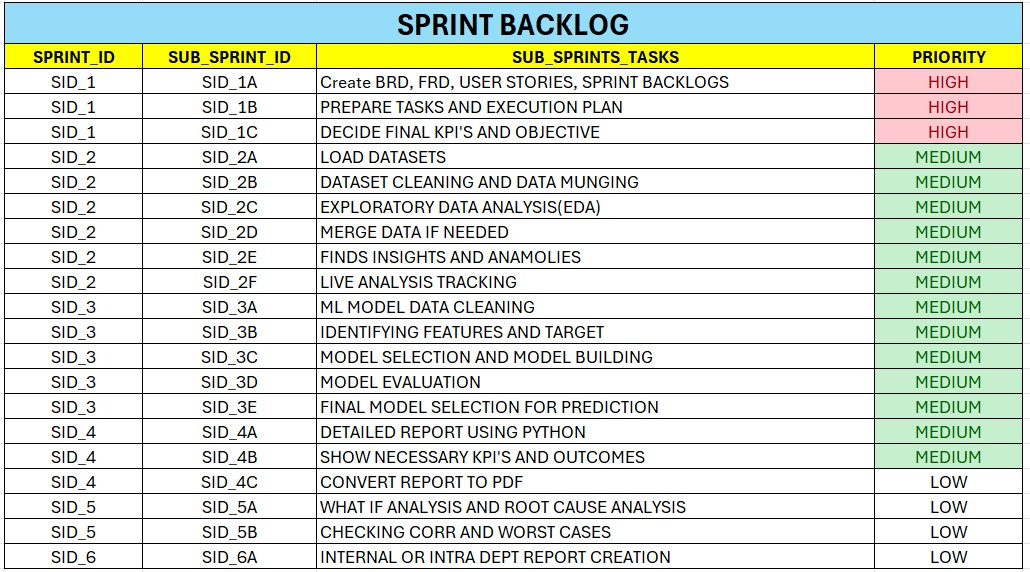

# Step 1: Load Important Modules

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # to remove or rename any file
import time
from sklearn.model_selection import train_test_split # sklearn used to build ML models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, recall_score
import pickle
import IPython as ip
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
import warnings
warnings.filterwarnings('ignore')
print("All Modules Loaded Successfully!!")

All Modules Loaded Successfully!!


# Step 2: Load Dataset


In [74]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/ActiveCustomer.xlsx"
active_customer_df=pd.read_excel(url)
print("Done")

Done


In [75]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/CreditCard.xlsx"
credit_card_df=pd.read_excel(url)
print("Done")

Done


In [76]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/ExitCustomer.xlsx"
exit_customer_card_df=pd.read_excel(url)
print("Done")

Done


In [77]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Gender.xlsx"
gender_df=pd.read_excel(url)
print("Done")

Done


In [78]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Geography.xlsx"
geography_df=pd.read_excel(url)
print("Done")

Done


In [79]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Bank_Churn.csv"
bank_churn_df=pd.read_csv(url)
print("Done")


Done


In [80]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/CustomerInfo.csv"
customer_info_df=pd.read_csv(url)
print("Done")


Done


In [81]:
all_dfs=[active_customer_df,credit_card_df,exit_customer_card_df,gender_df,geography_df,bank_churn_df,customer_info_df]
for i in all_dfs:
  print('='*50)
  display(i.sample(2))

,ActiveID,ActiveCategory
1,0,Inactive Member
0,1,Active Member


,CreditID,Category
1,0,non credit card holder
0,1,credit card holder


,ExitID,ExitCategory
1,0,Retain
0,1,Exit


,GenderID,GenderCategory
0,1,Male
1,2,Female


,GeographyID,GeographyLocation
1,2,Spain
0,1,France


,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ
1004,1005,15723685,601,3,2,26,4,105514.69,2,1,0,50070.59,0,08-05-2019
8345,8346,15763898,568,2,2,46,5,0.00,2,1,1,29372.62,0,07-06-2018


,CustomerId,Surname
2744,15667046,Tseng
9967,15603794,Pugliesi


# Step 3: EDA(Exploratory Data Analysis)

In [82]:
# step 3.1: show bank_churn_df sample
bank_churn_df.sample(5)

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ
3494,3495,15568120,681,1,2,37,6,69609.85,1,1,1,72127.83,0,25-04-2017
4291,4292,15770185,779,1,1,32,6,80728.15,1,1,0,86306.75,0,03-10-2016
6443,6444,15764927,753,1,1,92,5,121513.31,1,0,1,195563.99,0,12-05-2018
8052,8053,15770121,623,1,2,34,4,0.00,1,1,0,24255.21,0,28-09-2018
4562,4563,15795895,678,3,1,36,6,117864.85,2,1,0,27619.06,0,20-11-2016


In [83]:
# step 3.2: show df shape size
bank_churn_df.shape
# 14 colmuns and 10K rows

(10000, 14)

In [84]:
bank_churn_df.size

140000

In [85]:
# step 3.3:combine all dfs
merged_df=pd.merge(bank_churn_df,customer_info_df,on='CustomerId')
merged_df=pd.merge(merged_df,geography_df,on='GeographyID')
final_df=pd.merge(merged_df,gender_df,on='GenderID')
final_df

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory
0,1,15634602,619,1,2,42,7,0.00,1,1,1,101348.88,1,23-03-2016,Hargrave,France,Female
1,2,15647311,608,2,2,41,4,83807.86,1,0,1,112542.58,0,09-10-2018,Hill,Spain,Female
2,3,15619304,502,1,2,42,4,159660.80,3,1,0,113931.57,1,25-03-2019,Onio,France,Female
3,4,15701354,699,1,2,39,3,0.00,2,0,0,93826.63,0,24-10-2019,Boni,France,Female
4,5,15737888,850,2,2,43,3,125510.82,1,1,1,79084.10,0,22-11-2019,Mitchell,Spain,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,771,1,1,39,5,0.00,2,1,0,96270.64,0,25-03-2018,Obijiaku,France,Male
9996,9997,15569892,516,1,1,35,5,57369.61,1,1,1,101699.77,0,17-06-2018,Johnstone,France,Male
9997,9998,15584532,709,1,2,36,5,0.00,1,0,1,42085.58,1,18-03-2018,Liu,France,Female
9998,9999,15682355,772,3,1,42,3,75075.31,2,1,0,92888.52,1,12-11-2019,Sabbatini,Germany,Male


In [86]:
final_df.shape

(10000, 17)

In [87]:
# Step 3.4: Show column info
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RowNumber          10000 non-null  int64  
 1   CustomerId         10000 non-null  int64  
 2   CreditScore        10000 non-null  int64  
 3   GeographyID        10000 non-null  int64  
 4   GenderID           10000 non-null  int64  
 5   Age                10000 non-null  int64  
 6   Tenure             10000 non-null  int64  
 7   Balance            10000 non-null  float64
 8   NumOfProducts      10000 non-null  int64  
 9   HasCrCard          10000 non-null  int64  
 10  IsActiveMember     10000 non-null  int64  
 11  EstimatedSalary    10000 non-null  float64
 12  Exited             10000 non-null  int64  
 13  Bank DOJ           10000 non-null  object 
 14  Surname            10000 non-null  object 
 15  GeographyLocation  10000 non-null  object 
 16  GenderCategory     1000

In [88]:
# Step 3.5: Drop Nan or missing values
final_df.dropna(inplace=True)
print("Done")

Done


In [89]:
# Step 3.6: Show data stats
final_df.describe(include="number")

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,1.749500,1.454300,38.921800,4.86430,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,0.830433,0.497932,10.487806,1.21525,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,1.000000,1.000000,18.000000,3.00000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,1.000000,1.000000,32.000000,4.00000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,1.000000,1.000000,37.000000,5.00000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,3.000000,2.000000,44.000000,6.00000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,3.000000,2.000000,92.000000,7.00000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [90]:
# Step 3.7: Show Categorical Data stats
final_df.describe(include='object')


,Bank DOJ,Surname,GeographyLocation,GenderCategory
count,10000,10000,10000,10000
unique,1332,2932,3,2
top,16-12-2017,Smith,France,Male
freq,35,32,5014,5457


In [91]:
# step 3.8: Show data Correalation
corr=final_df.corr(numeric_only=True)
corr
# corr range from -1 to +1
# -1 represents: Highly negative correlation
# +1 represents: Highly positive correlation
# 0 represents: No correlation

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,-0.005196,-0.018196,0.000783,0.002901,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.000821,0.002641,0.009497,0.003884,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,0.008267,0.002857,-0.003965,-0.007355,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
GeographyID,-0.005196,0.000821,0.008267,1.000000,0.016936,0.048092,-0.003858,0.348700,-0.006180,0.004036,-0.012692,0.007382,0.153771
GenderID,-0.018196,0.002641,0.002857,0.016936,1.000000,0.027544,-0.008018,-0.012087,0.021859,-0.005766,-0.022544,0.008112,0.106512
Age,0.000783,0.009497,-0.003965,0.048092,0.027544,1.000000,0.010788,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.002901,0.003884,-0.007355,-0.003858,-0.008018,0.010788,1.000000,0.001457,-0.029927,0.003857,-0.007576,0.005744,0.000699
Balance,-0.009067,-0.012419,0.006268,0.348700,-0.012087,0.028308,0.001457,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.006180,0.021859,-0.030680,-0.029927,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,0.004036,-0.005766,-0.011721,0.003857,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138


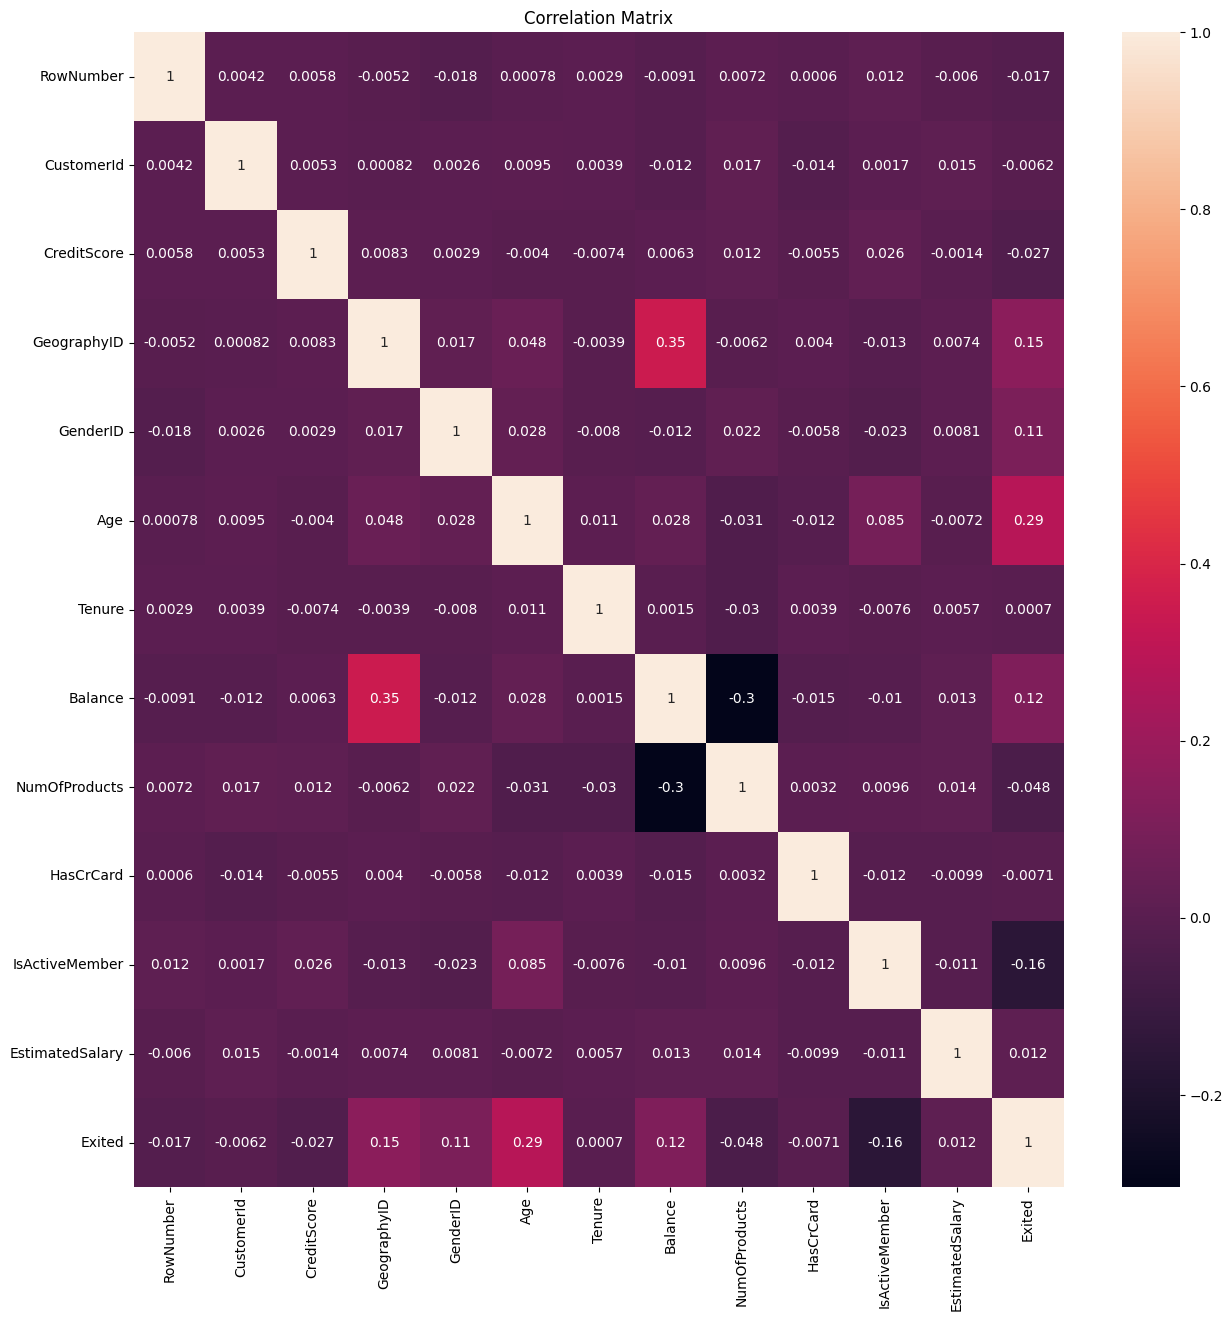

In [92]:
# Step 3.9
plt.figure(figsize=(15,15))
plt.title("Correlation Matrix")
sns.heatmap(corr,annot=True)
plt.show()

In [100]:
# step 3.10: Divide columns into required objects
textual_columns=final_df.select_dtypes('object').columns
numerical_columns=final_df.select_dtypes('number').columns
print("Textual Columns:\n",textual_columns)
print('='*100)
print("Numerical Columns:\n",numerical_columns)


Textual Columns:
 Index(['Surname', 'GeographyLocation', 'GenderCategory'], dtype='object')
Numerical Columns:
 Index(['CustomerId', 'CreditScore', 'GeographyID', 'GenderID', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')


In [98]:
# Step 3.11: Change Bank DOJ to datetime Dtype
final_df['Bank DOJ']=pd.to_datetime(final_df['Bank DOJ'])
print("Done")

Done


In [95]:
# step 3.12: Drop Unwanted Column
final_df.drop('RowNumber',axis=1,inplace=True)
# axis=1 : means drop column, axis=0 : means drop row
# inplace=True: means: apply changes in actual dataset
print("Done")

Done


In [96]:
final_df.columns

Index(['CustomerId', 'CreditScore', 'GeographyID', 'GenderID', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Bank DOJ', 'Surname', 'GeographyLocation',
       'GenderCategory'],
      dtype='object')

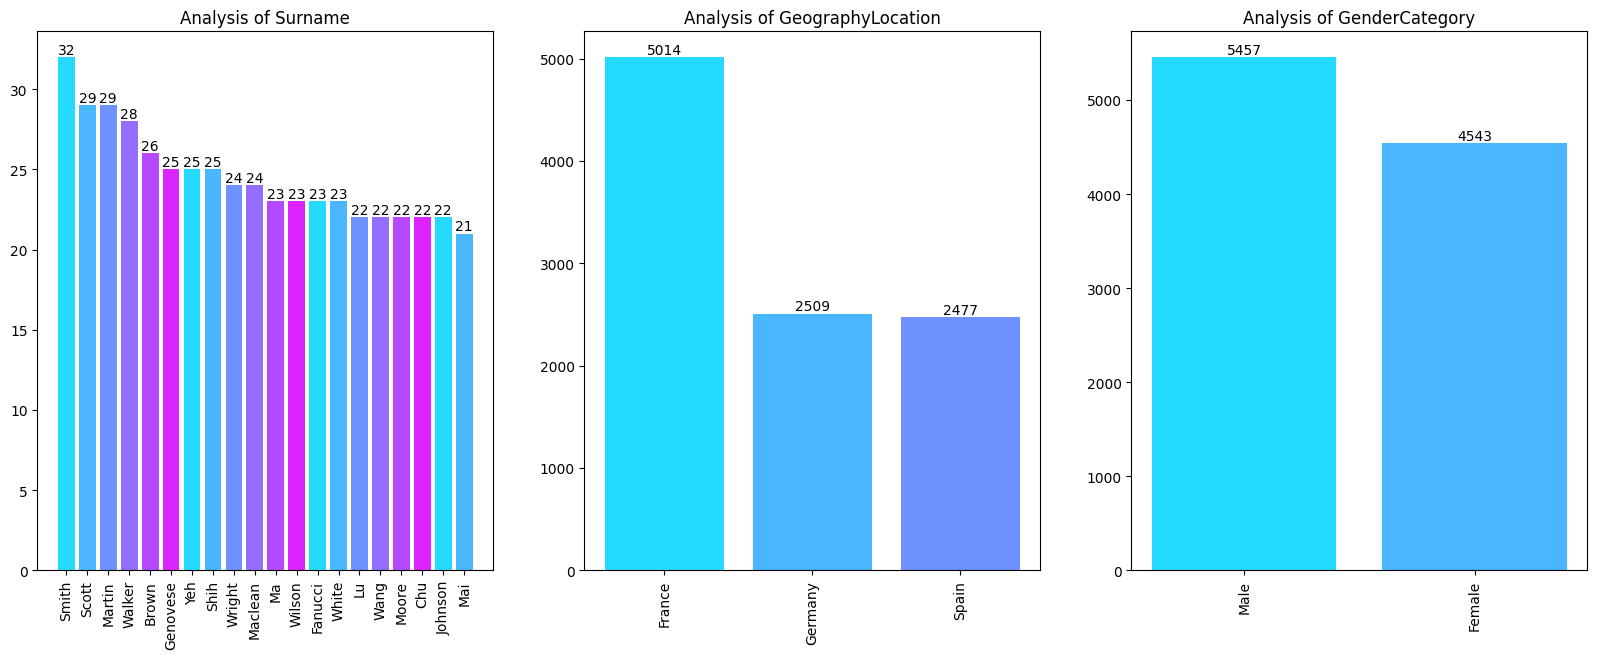

In [101]:
# step 3.13: Univariate Analysis(single column analysis)
plt.figure(figsize=(20,7))
for i,j in enumerate(textual_columns): # i->index, j->column name enumerate->to get index and value at the same time
  plt.subplot(1,3,i+1) # multiple plots at once
  temp_df=final_df[j].value_counts().head(20) # value_counts- to group data and count its value frequency
  x=temp_df.index
  y=temp_df.values
  plt.title(f"Analysis of {j}")
  ax=plt.bar(x,y,color=sns.color_palette('cool')) # sns.colorpalette-> to change color shades
  plt.bar_label(ax)
  plt.xticks(rotation=90)
plt.show() # out of loop



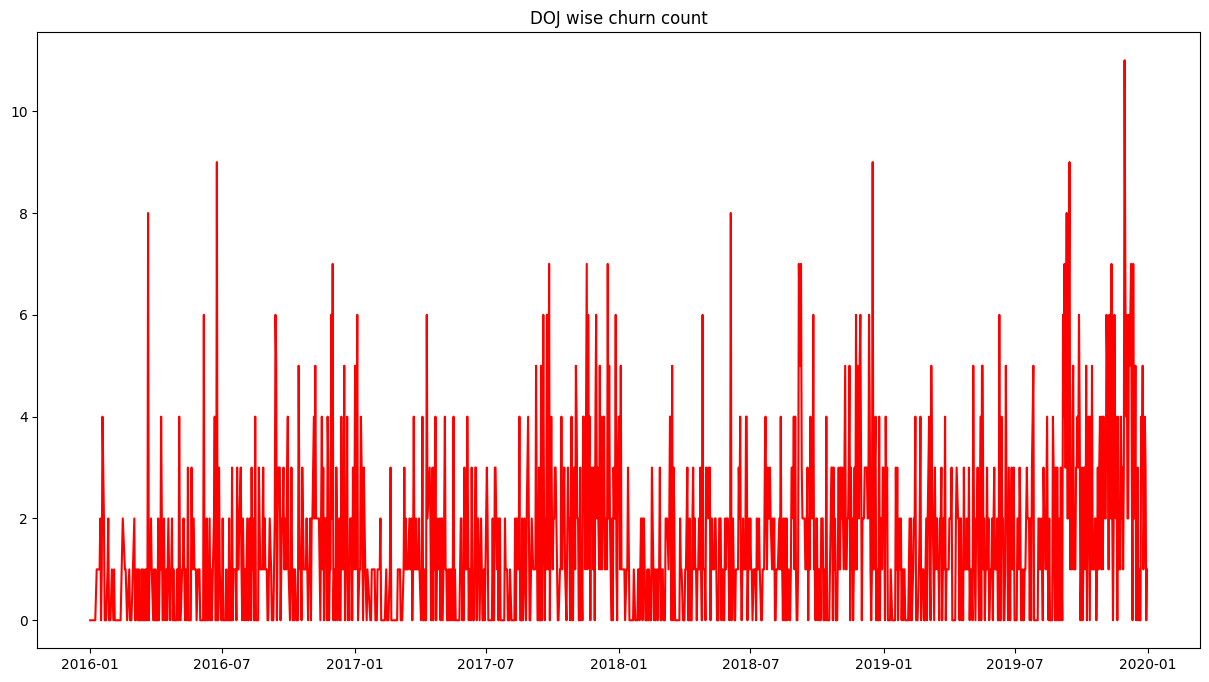

In [102]:
# step 3.14: Bivariate Analysis
# Show Bank DOJ wise churn count
plt.figure(figsize=(15,8))
plt.title('DOJ wise churn count')
temp_df=final_df.groupby('Bank DOJ')['Exited'].sum()
x=temp_df.index
y=temp_df.values
plt.plot(x,y,color='r',linestyle='-')
plt.show()

In [103]:
# Step 3.15: Create new column for monthly and weekly analytics
final_df['Month']=final_df['Bank DOJ'].dt.month_name()
final_df['Day']=final_df['Bank DOJ'].dt.day_name() # dt means-> datetime
final_df.sample()


,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory,Month,Day
2199,15770174,762,1,1,29,7,141389.06,1,1,0,54122.89,0,2016-07-16,Piazza,France,Male,July,Saturday


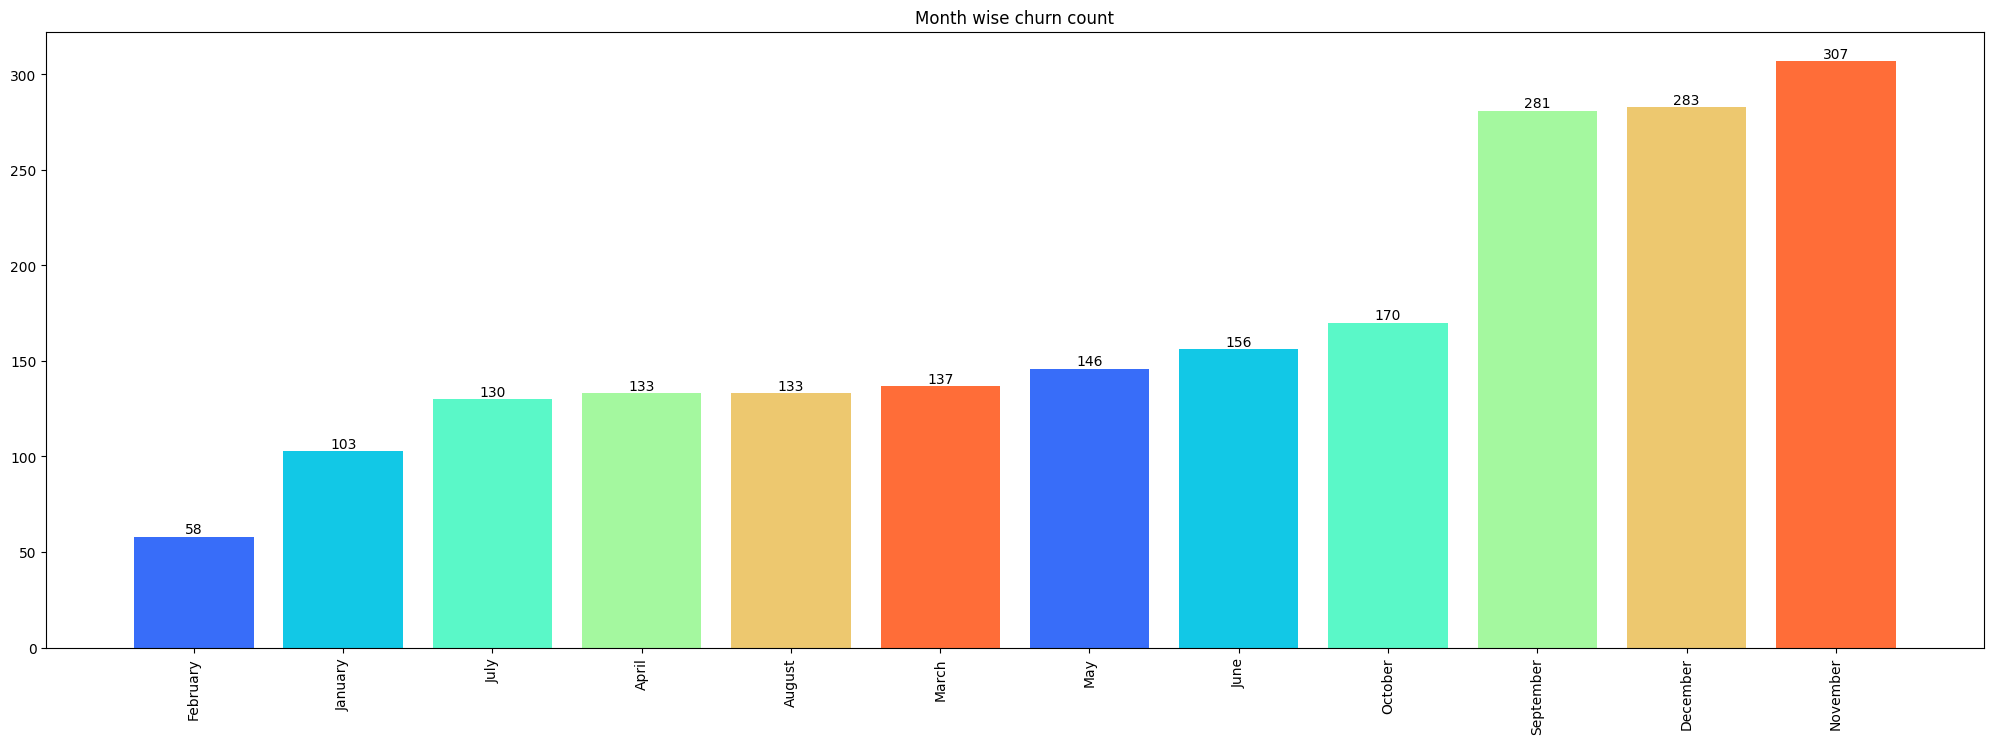

In [104]:
# Step 3.16: Show Monthly Churn Analysis

plt.figure(figsize=(25, 8))
plt.title("Month wise churn count")

temp_df = final_df.groupby('Month')['Exited'].sum().sort_values()

x = temp_df.index
y = temp_df.values

ax = plt.bar(x, y, color=sns.color_palette('rainbow'))

plt.bar_label(ax)
plt.xticks(rotation=90)

plt.show()

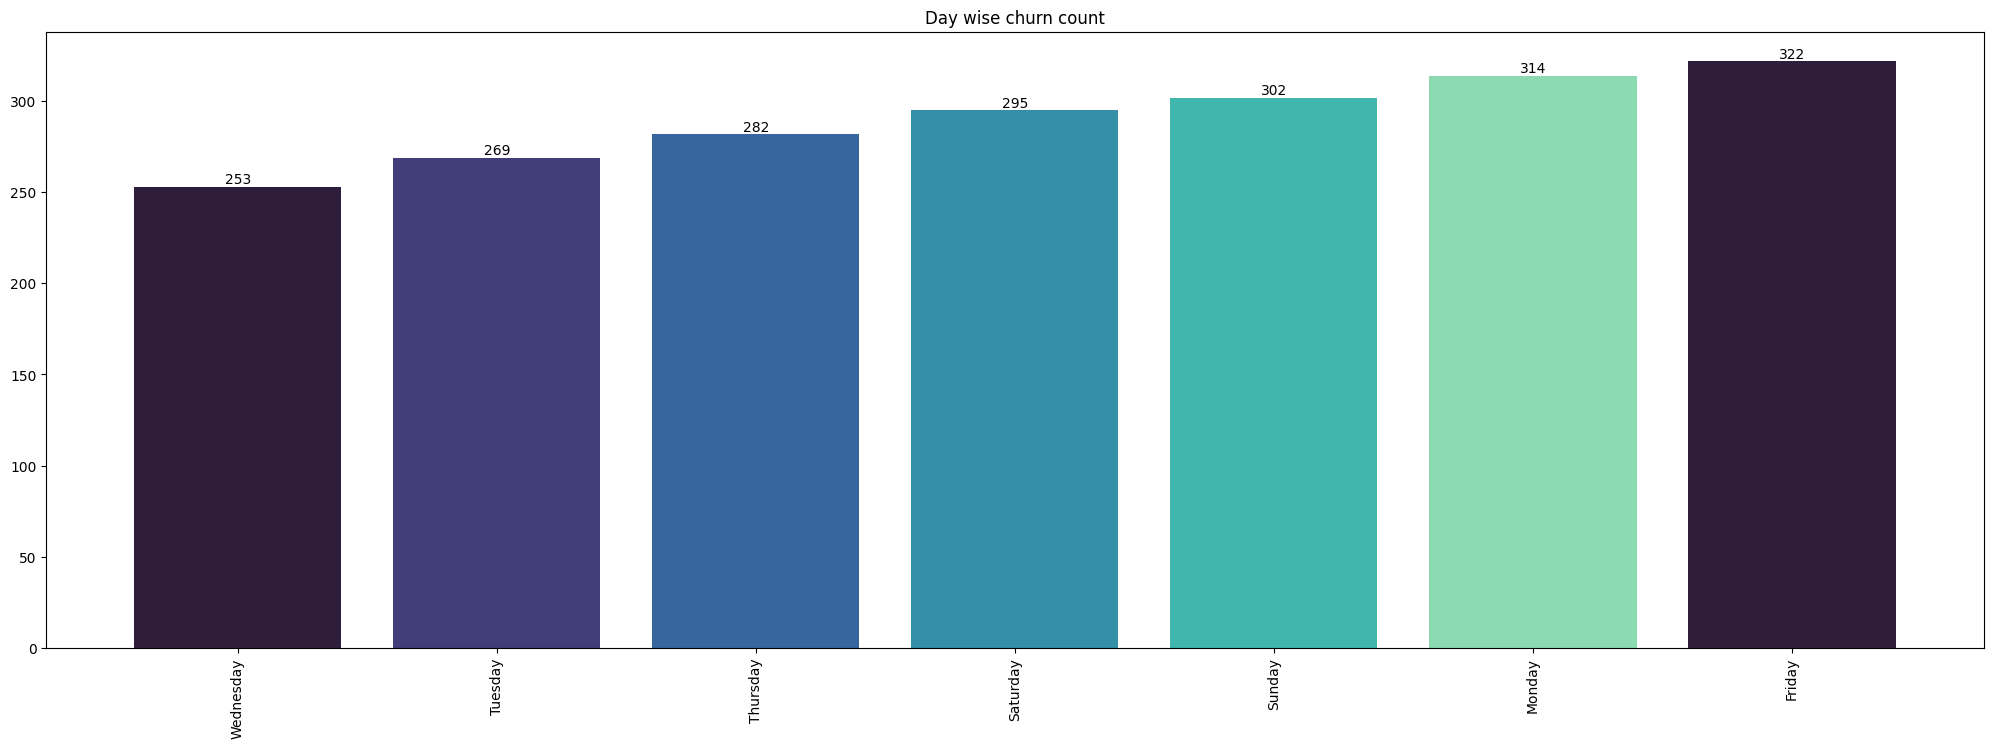

In [105]:
# Step 3.17: Show Daywise Churn Analysis

plt.figure(figsize=(25, 8))
plt.title("Day wise churn count")

temp_df = final_df.groupby('Day')['Exited'].sum().sort_values()

x = temp_df.index
y = temp_df.values

ax = plt.bar(x, y, color=sns.color_palette('mako'))

plt.bar_label(ax)
plt.xticks(rotation=90)

plt.show()

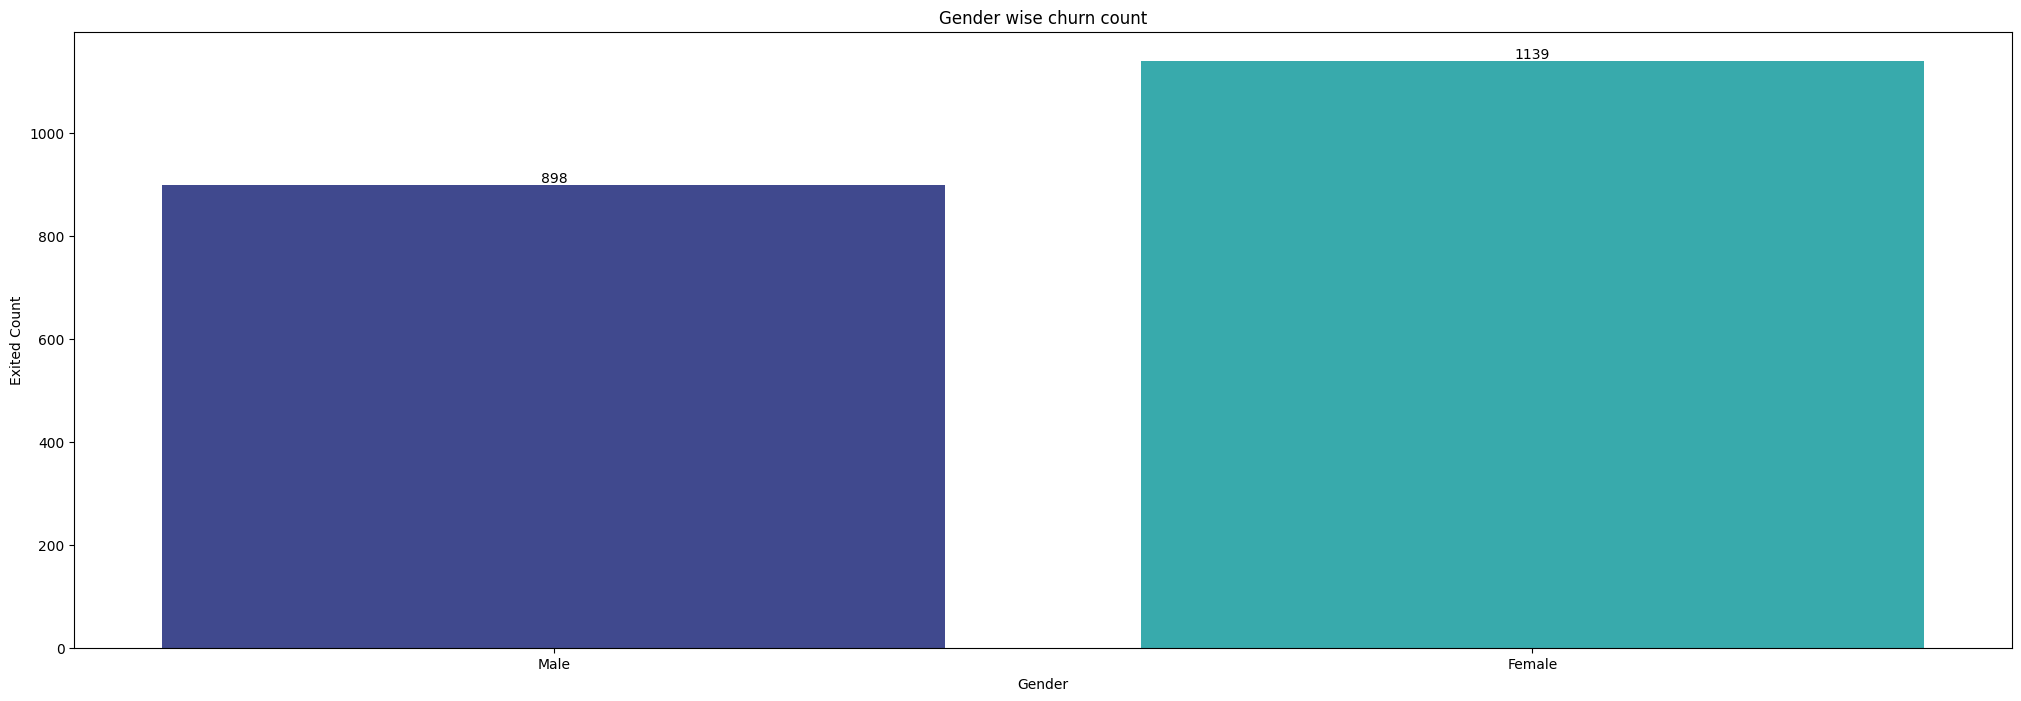

In [106]:
# Step 3.18: Show Gender Wise Churn Analysis
plt.figure(figsize=(25, 8))
plt.title("Gender wise churn count")

temp_df = final_df.groupby('GenderCategory')['Exited'].sum().sort_values()

x = temp_df.index
y = temp_df.values

ax = plt.bar(x, y, color=sns.color_palette('mako',len(x)))

plt.bar_label(ax)
plt.xlabel("Gender")
plt.ylabel("Exited Count")

plt.show()


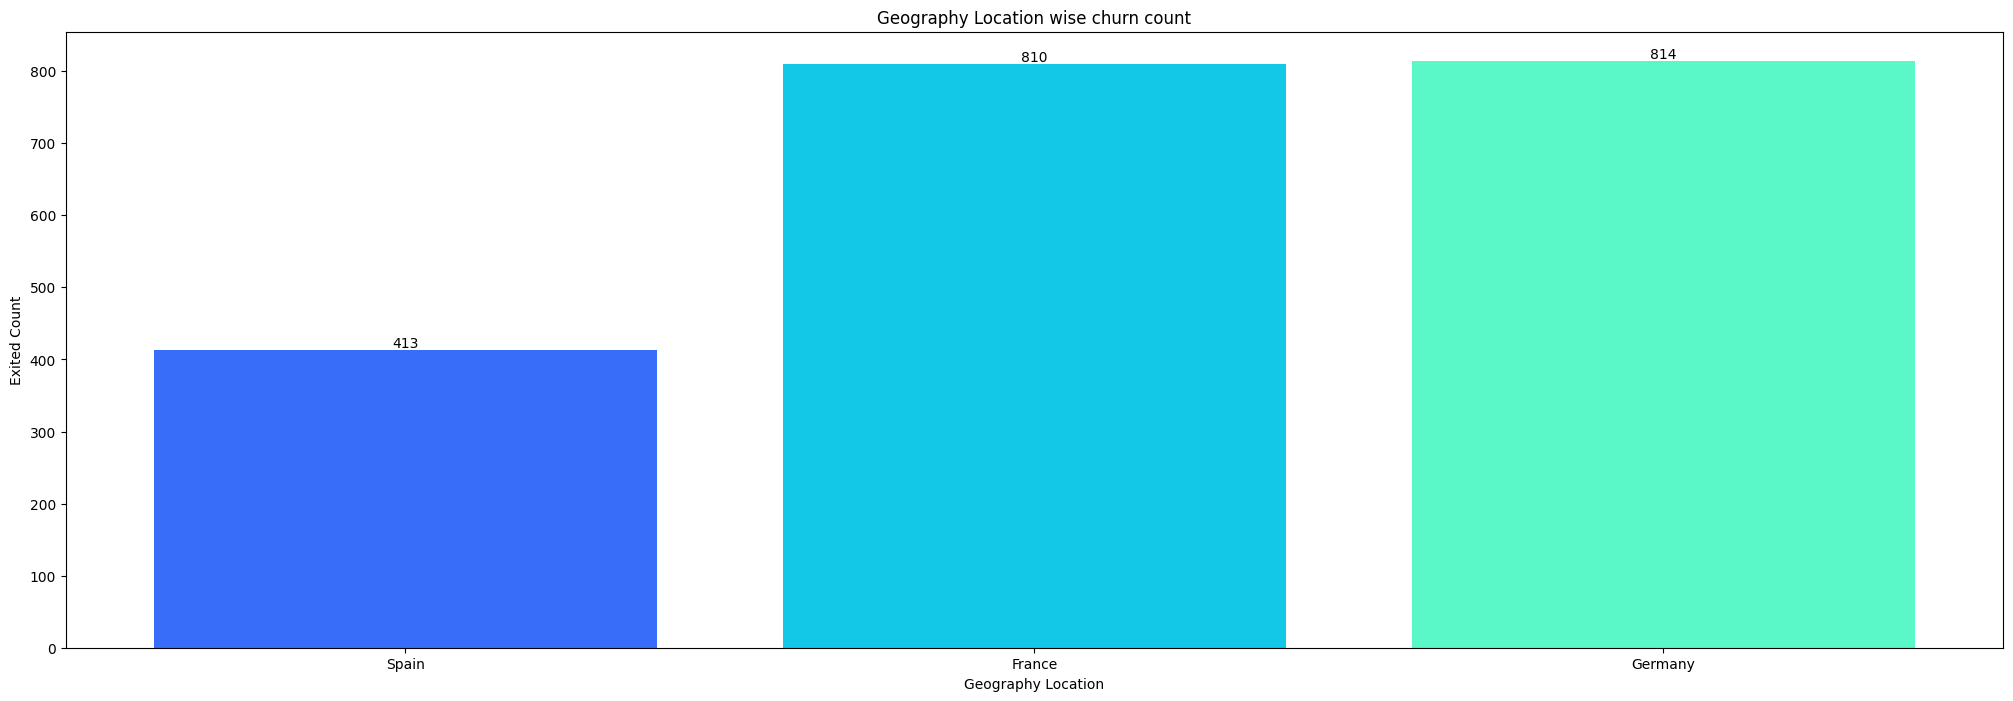

In [107]:
# Step 3.19: Show Geography Location Wise Churn Analysis
plt.figure(figsize=(25, 8))
plt.title("Geography Location wise churn count")

temp_df = final_df.groupby('GeographyLocation')['Exited'].sum().sort_values()

x = temp_df.index
y = temp_df.values

ax = plt.bar(x, y, color=sns.color_palette('rainbow'))

plt.bar_label(ax)
plt.xlabel("Geography Location")
plt.ylabel("Exited Count")

plt.show()

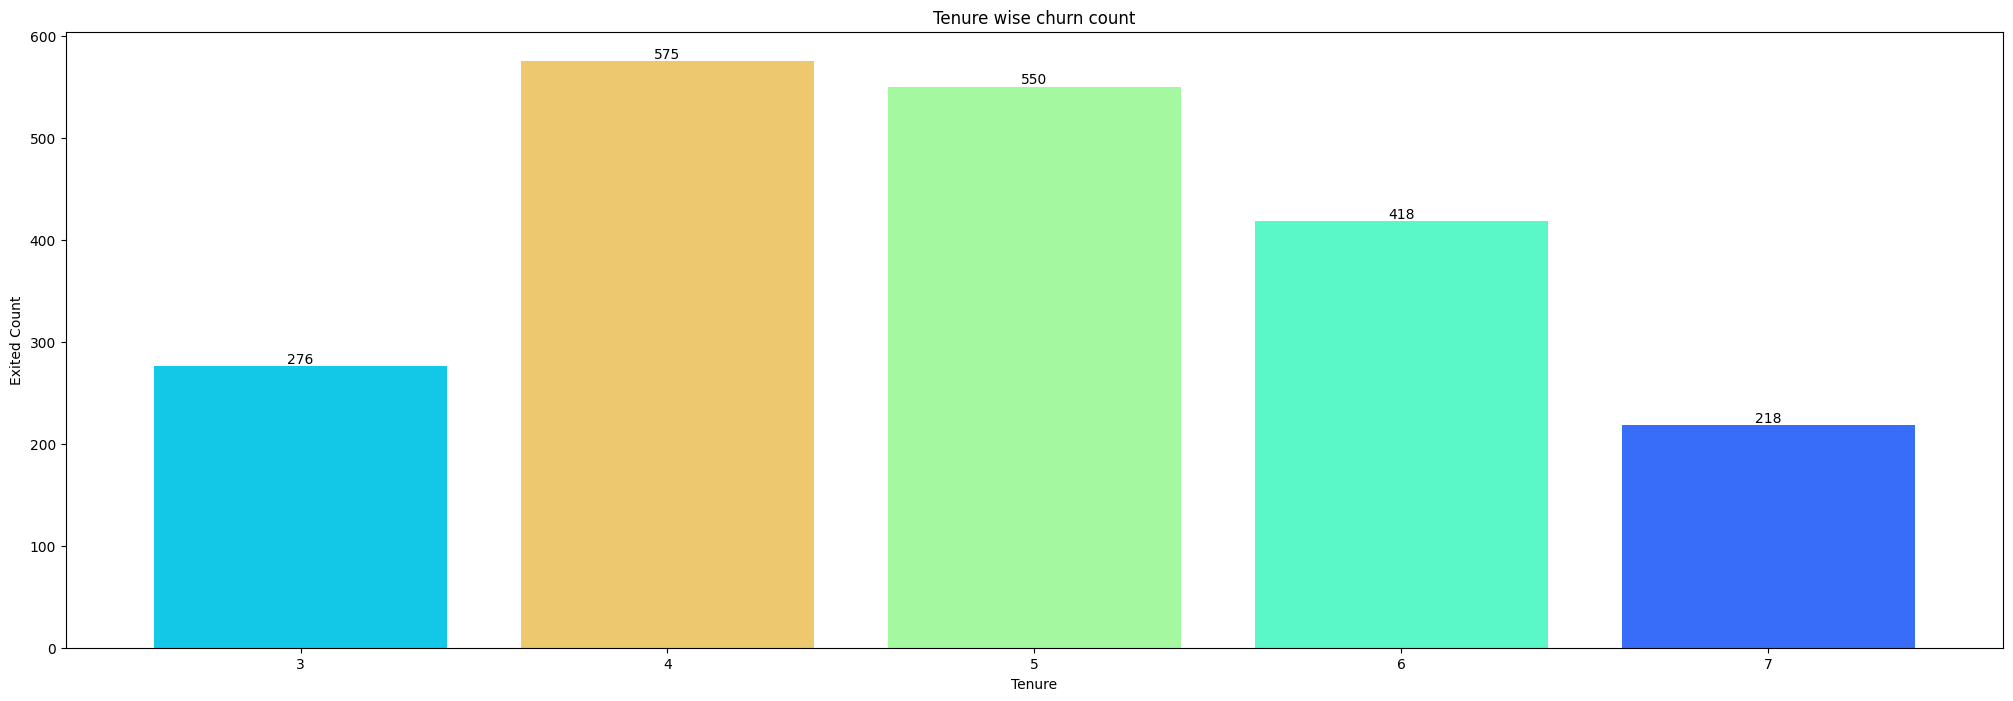

In [108]:
# Step 3.20: Show Tenure Wise Churn Analysis
plt.figure(figsize=(25, 8))
plt.title("Tenure wise churn count")

temp_df = final_df.groupby('Tenure')['Exited'].sum().sort_values()

x = temp_df.index
y = temp_df.values

ax = plt.bar(x, y, color=sns.color_palette('rainbow'))

plt.bar_label(ax)
plt.xlabel("Tenure")
plt.ylabel("Exited Count")

plt.show()

In [109]:
# Step 3.21: Drop unwated columns
ml_drop_columns = ['CustomerId', 'GeographyID', 'GenderID', 'Bank DOJ', 'Surname', 'Day']

ml_df = final_df.drop(ml_drop_columns, axis = 1, inplace=False)
ml_df.sample(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
3237,802,38,5,0.00,2,0,1,57764.65,0,Spain,Male,June
8187,603,39,3,162390.52,2,1,0,54702.66,0,Spain,Female,September
4367,573,50,4,159304.07,1,0,1,155915.24,1,Spain,Male,May
896,718,35,7,0.00,2,1,0,94820.85,0,France,Male,March
347,643,59,7,170331.37,1,1,1,32171.79,0,Germany,Male,June


# Step 4: Feature Engineering


*   ML only works with numerical data, if we are getting any textual data
*   We need to convert textual data to numerical


*   Technique is called Feature Engineering
*   Here GeographyLocation, GenderCategory or Month textual in nature





In [110]:
# Types of technique
# OHE: one hot encoding
# map: using dict
# apply lambda method
# categorical encoding
# get dummies
# ordinal encoding
# TF-IDF
# BOW: bag of words
# advance: countvectorizer, word embeddings
# more advance: vector database using cosine technique

In [111]:
# Step: 4.1
import calendar
months_name=list (calendar.month_name)[1:]
index=list(range(len(months_name)))
map=dict(zip(months_name,index)) #zip: bind two object together and give dict
ml_df['Month']=ml_df['Month'].map(map) # .map: method to map the key with value.
ml_df.sample()
# run this step only once

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
3844,681,38,4,153722.47,1,1,0,101319.76,0,France,Male,3


In [112]:
ml_df['GeographyLocation'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [113]:
ml_df['GenderCategory']=ml_df['GenderCategory'].map({'Male':0,'Female':1})
ml_df['GeographyLocation']=ml_df['GeographyLocation'].map({'France':0,'Spain':1,'Germany':2})
ml_df.sample()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
1285,520,63,3,162278.32,1,1,1,34765.33,0,1,1,11


In [114]:
#Step 4.2: show target vs feature corr
ml_df.corr()['Exited'].sort_values(ascending=False)

,Exited
Exited,1.000000
Age,0.285323
GeographyLocation,0.153771
Balance,0.118533
GenderCategory,0.106512
EstimatedSalary,0.012097
Month,0.002312
Tenure,0.000699
HasCrCard,-0.007138
CreditScore,-0.027094


In [115]:
ml_df.sample(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
1762,758,34,3,154139.45,1,1,1,60728.89,0,0,1,11
5489,728,33,3,129907.63,1,0,1,36083.96,0,0,0,9
9095,850,38,3,102741.15,2,0,1,23974.85,0,2,1,11
6927,601,37,7,0.00,1,0,0,20708.60,0,0,1,6
9946,669,33,5,0.00,2,0,1,107221.03,0,0,1,10


# Step 5: Divide data in features vs target


In [116]:
X=ml_df.drop('Exited',axis=1) #X-> Capital and in Dataframe
y=ml_df['Exited']             #y-> small and in series
print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


# Step 6: Divide the data into train and test

---



In [117]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
random_state=42,
test_size=0.2)
print("X_train-Shape: ", X_train.shape)
print("X_test-Shape: ", X_test.shape)
print("y_train-Shape: ", y_train.shape)
print("y_test-Shape: ", y_test.shape)

X_train-Shape:  (8000, 11)
X_test-Shape:  (2000, 11)
y_train-Shape:  (8000,)
y_test-Shape:  (2000,)


# Step 7: To bo Continued..